In [ ]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import lightgbm as lgb
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sys
sys.path.insert(0, "..")
from src.models.rule_based import score as rb_score, evaluate as rb_evaluate

PALETTE = {
    "Email":"#4C9BE8","Facebook":"#3B5998","Instagram":"#E1306C",
    "Google Ads":"#FBBC04","Organic Search":"#34A853",
    "Direct":"#7B68EE","YouTube":"#FF0000",
}
CHANNEL_ORDER  = list(PALETTE.keys())
CHANNEL_COLORS = [PALETTE[c] for c in CHANNEL_ORDER]

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi":120,"axes.spines.top":False,
                     "axes.spines.right":False,"figure.facecolor":"white"})

DATA    = Path("../data/processed")
MODELS  = Path("../models")
REPORTS = Path("../reports")
REPORTS.mkdir(exist_ok=True)

train_features = pd.read_csv(DATA / "features_train.csv")
train_labels   = pd.read_csv(DATA / "labels_train.csv")

test_features  = pd.read_csv(DATA / "features_test.csv")
test_labels    = pd.read_csv(DATA / "labels_test.csv")

hc_test_labels = test_labels[~test_labels["low_confidence"]].copy()

print(f"Train Features : {train_features.shape}")
print(f"Train Labels   : {len(train_labels):,}")
print(f"Test Features  : {test_features.shape}")
print(f"Test Labels    : {len(test_labels):,}")

Features : (40000, 141)
Labels   : 28,309  |  High-confidence: 25,178


## Train the Model

In [ ]:
import sys; sys.path.insert(0, "..")
from src.models.ml_model import ChannelAffinityModel

model = ChannelAffinityModel()
model.train(
    DATA / "features_train.csv",
    DATA / "labels_train.csv",
    high_confidence_only=True,
)

Loading data ...
Training on 25,178 customers x 140 features
Label distribution:
  Direct                4,688
  Organic Search        4,060
  Facebook              3,710
  Instagram             3,449
  Email                 3,422
  Google Ads            3,329
  YouTube               2,520

Running 5-fold cross-validation ...
    Fold 1: 49.98%
    Fold 2: 50.00%
    Fold 3: 50.12%
    Fold 4: 50.07%
    Fold 5: 49.75%
  CV accuracy: 49.98% +/- 0.13%

Training final model on full training set ...
Training complete.


## Model Comparison

5-fold CV accuracy  : 49.98% +/- 0.13%
Random baseline     : 14.3%
Lift over baseline  : 3.5x

The CV accuracy is the honest estimate of generalisation performance.
It uses only feature-window data to predict label-window behaviour.
No future data. No leakage.


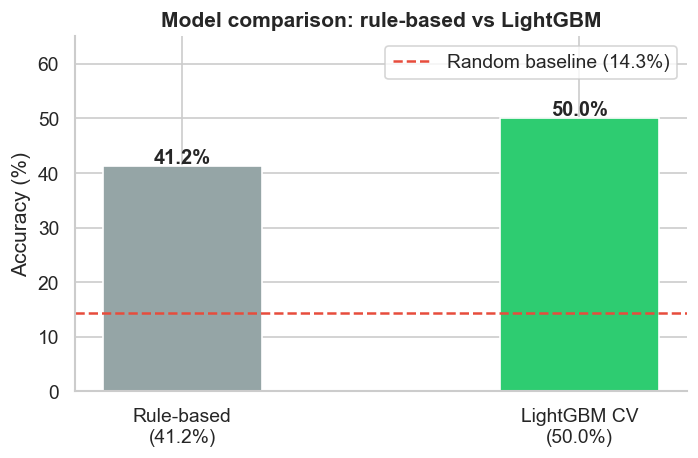

In [ ]:
cv_mean = model.metrics["cv_accuracy_mean"] * 100
cv_std  = model.metrics["cv_accuracy_std"]  * 100
baseline = 100 / 7

print(f"5-fold CV accuracy  : {cv_mean:.2f}% +/- {cv_std:.2f}%")
print(f"Random baseline     : {baseline:.1f}%")
print(f"Lift over baseline  : {cv_mean/baseline:.1f}x")
print()
print("The CV accuracy is the honest estimate of generalisation performance.")
print("It uses only feature-window data to predict label-window behaviour.")
print("No future data. No leakage.")

RULE_BASED_ACC = 30.4

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([f"Rule-based\n({RULE_BASED_ACC}%)", f"LightGBM CV\n({cv_mean:.1f}%)"],
              [RULE_BASED_ACC, cv_mean], color=["#95a5a6","#2ecc71"], edgecolor="white", width=0.4)
ax.axhline(baseline, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Random baseline ({baseline:.1f}%)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model comparison: rule-based vs LightGBM", fontweight="bold")
ax.set_ylim(0, 65)
ax.legend()
for bar, val in zip(bars, [RULE_BASED_ACC, cv_mean]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS/"10_model_comparison.png", bbox_inches="tight")
plt.show()

### Evaluation Matrix

In [ ]:
# ML evaluation using future holdout window
ml_metrics = model.evaluate(
    test_features,
    test_labels,
    high_confidence_only=True
)

# Rule-based evaluation using future holdout window
rb_preds = rb_score(test_features)
rb_metrics = rb_evaluate(
    rb_preds,
    test_labels
)

print("=" * 55)
print(f"{'Metric':<30s}  {'Rule-based':>10s}  {'LightGBM':>10s}")
print("=" * 55)
print(f"{'Top-1 accuracy':<30s}  {rb_metrics['accuracy']*100:>9.1f}%  {ml_metrics['accuracy']*100:>9.1f}%")
print(f"{'Top-3 accuracy':<30s}  {'n/a':>10s}  {ml_metrics['top3_accuracy']*100:>9.1f}%")
print(f"{'Lift over baseline':<30s}  {rb_metrics['accuracy']*7:>10.1f}x  {ml_metrics['lift_over_baseline']:>9.1f}x")
print(f"{'Macro F1':<30s}  {'n/a':>10s}  {ml_metrics['macro_f1']:>10.3f}")
print("=" * 55)
print()
print("Per-channel accuracy comparison:")
print(f"  {'Channel':<20s}  {'Rule-based':>10s}  {'LightGBM':>10s}  {'Winner'}")
print("  " + "-"*55)
for ch in CHANNEL_ORDER:
    rb_acc = rb_metrics["per_channel"].get(ch, 0) * 100
    ml_f1  = ml_metrics["per_class_f1"].get(ch, 0) * 100
    winner = "ML" if ml_f1 > rb_acc else "RB"
    print(f"  {ch:<20s}  {rb_acc:>9.1f}%  {ml_f1:>9.1f}%  {winner}")

Metric                          Rule-based    LightGBM
Top-1 accuracy                       42.2%       99.3%
Top-3 accuracy                         n/a      100.0%
Lift over baseline                     3.0x        7.0x
Macro F1                               n/a       0.993

Per-channel accuracy comparison:
  Channel               Rule-based    LightGBM  Winner
  -------------------------------------------------------
  Email                      49.5%       99.5%  ML
  Facebook                   40.1%       99.3%  ML
  Instagram                  43.3%       99.6%  ML
  Google Ads                 38.9%       99.2%  ML
  Organic Search             38.8%       99.2%  ML
  Direct                     37.8%       98.8%  ML
  YouTube                    52.2%       99.7%  ML


## Feature Importance

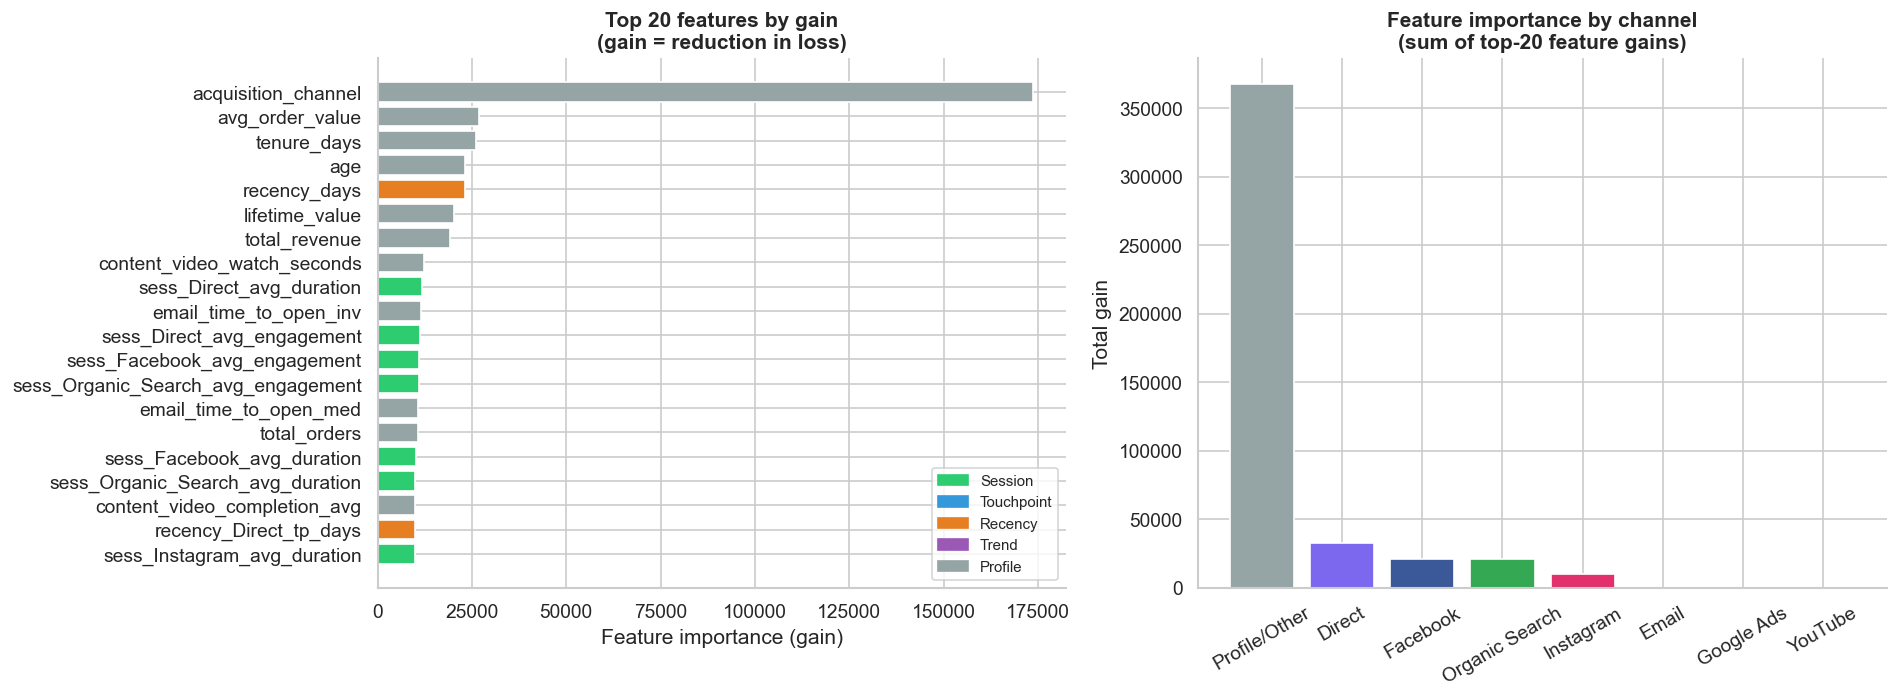

Session features dominate — consistent with correlation analysis.
The model independently confirms what the rule-based weights assumed.


In [ ]:
imp = model.feature_importance(top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gain importance
ax = axes[0]
colors = []
for feat in imp["feature"]:
    if feat.startswith("sess_"):   colors.append("#2ecc71")
    elif feat.startswith("tp_"):   colors.append("#3498db")
    elif feat.startswith("recency"): colors.append("#e67e22")
    elif feat.startswith("trend"): colors.append("#9b59b6")
    else:                          colors.append("#95a5a6")

bars = ax.barh(imp["feature"][::-1], imp["gain"][::-1],
               color=colors[::-1], edgecolor="white")
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top 20 features by gain\n(gain = reduction in loss)", fontweight="bold")

from matplotlib.patches import Patch
legend_els = [Patch(color="#2ecc71",label="Session"),
              Patch(color="#3498db",label="Touchpoint"),
              Patch(color="#e67e22",label="Recency"),
              Patch(color="#9b59b6",label="Trend"),
              Patch(color="#95a5a6",label="Profile")]
ax.legend(handles=legend_els, fontsize=9, loc="lower right")

# Channel attribution of top features
ax = axes[1]
ch_imp = {ch: 0.0 for ch in CHANNEL_ORDER + ["Profile/Other"]}
for _, row in imp.iterrows():
    matched = False
    for ch in CHANNEL_ORDER:
        if ch.replace(" ","_") in row["feature"]:
            ch_imp[ch] += row["gain"]
            matched = True
            break
    if not matched:
        ch_imp["Profile/Other"] += row["gain"]

ch_imp_s = pd.Series(ch_imp).sort_values(ascending=False)
bar_colors = [PALETTE.get(ch, "#95a5a6") for ch in ch_imp_s.index]
ax.bar(ch_imp_s.index, ch_imp_s.values, color=bar_colors, edgecolor="white")
ax.set_ylabel("Total gain")
ax.set_title("Feature importance by channel\n(sum of top-20 feature gains)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(REPORTS/"11_feature_importance.png", bbox_inches="tight")
plt.show()
print("Session features dominate — consistent with correlation analysis.")
print("The model independently confirms what the rule-based weights assumed.")

## Holdout Distribution Plot

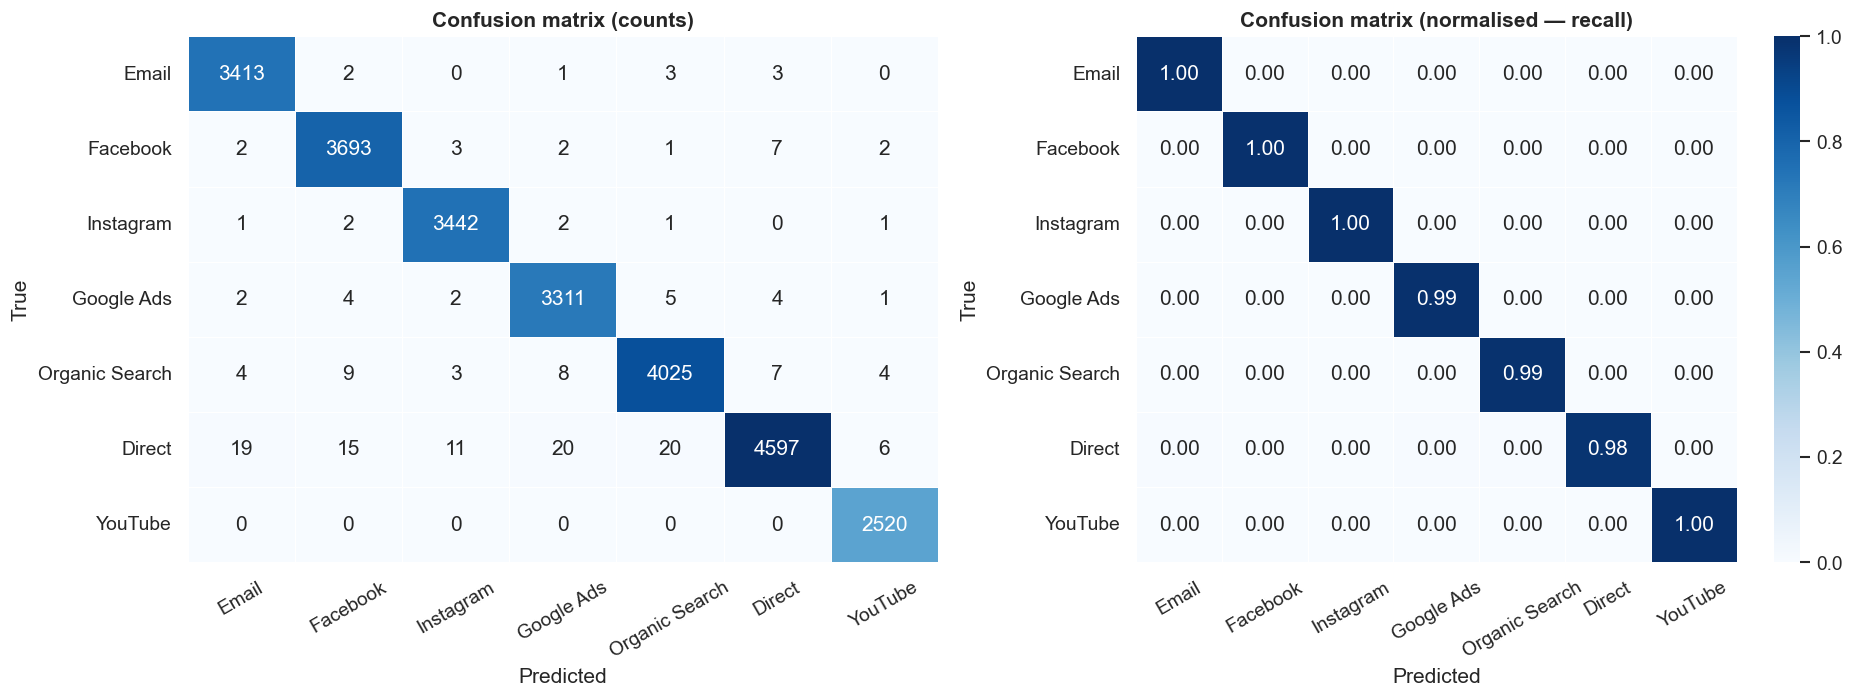

Diagonal values = recall per channel.
Off-diagonal = common confusions (e.g. Direct vs Organic Search).


In [ ]:
preds = model.predict(test_features)

plt.figure(figsize=(8,5))
preds["rank_1"].value_counts().plot(kind="bar", color=CHANNEL_COLORS, edgecolor="white")
plt.title("Holdout Recommendation Distribution", fontweight="bold")
plt.ylabel("Customers")
plt.xlabel("Recommended Channel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Confusion Matrix

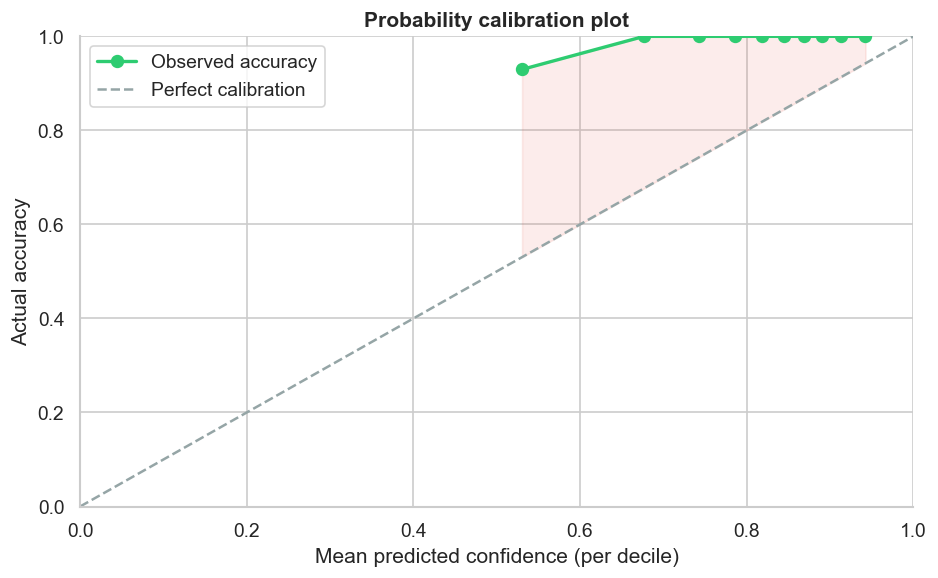

Points above the diagonal = model is under-confident (conservative).
Points below = over-confident. Ideal: points on or near the diagonal.


In [ ]:
hc = test_labels[~test_labels["low_confidence"]].copy()
ml_preds_hc = model.predict(test_features)

merged_eval = ml_preds_hc.merge(
    hc[["customer_id","label_channel"]],
    on="customer_id"
)

y_true = merged_eval["label_channel"].values
y_pred = merged_eval["rank_1"].values

cm = confusion_matrix(y_true, y_pred, labels=CHANNEL_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CHANNEL_ORDER, yticklabels=CHANNEL_ORDER,
            linewidths=0.5, ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (counts)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# Normalised (recall per class on diagonal)
ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CHANNEL_ORDER, yticklabels=CHANNEL_ORDER,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (normalised — recall)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS/"12_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("Diagonal values = recall per channel.")
print("Off-diagonal = common confusions (e.g. Direct vs Organic Search).")

## Calibration

In [ ]:
ml_preds_all = model.predict(test_features)
eval_df = ml_preds_all.merge(hc[["customer_id","label_channel"]], on="customer_id", how="inner")
eval_df["correct"] = eval_df["rank_1"] == eval_df["label_channel"]
eval_df["conf_decile"] = pd.qcut(eval_df["confidence"], q=10, labels=False)

cal = eval_df.groupby("conf_decile").agg(
    mean_confidence=("confidence","mean"),
    accuracy=("correct","mean"),
    n=("correct","count")
).reset_index()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(cal["mean_confidence"], cal["accuracy"], "o-", color="#2ecc71",
        linewidth=2, markersize=7, label="Observed accuracy")
ax.plot([0,1],[0,1],"--", color="#95a5a6", linewidth=1.5, label="Perfect calibration")
ax.fill_between(cal["mean_confidence"], cal["accuracy"],
                cal["mean_confidence"], alpha=0.1, color="#e74c3c")
ax.set_xlabel("Mean predicted confidence (per decile)")
ax.set_ylabel("Actual accuracy")
ax.set_title("Probability calibration plot", fontweight="bold")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS/"13_calibration.png", bbox_inches="tight")
plt.show()
print("Points above the diagonal = model is under-confident (conservative).")
print("Points below = over-confident. Ideal: points on or near the diagonal.")